# Refined 3 x 4 improvement comparison

This notebook keeps `plot_improvement.ipynb` unchanged and rebuilds the 3 x 4 comparison figure with clearer small multiples, shared labels, a single legend, and cleaner percentage axes.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
ROOT = Path.cwd()
LABEL_FILE = ROOT / "taillarde_labels.txt"
RESULT_DIR = ROOT / "results"
OUTPUT_PDF = ROOT / "comparison2_refined.pdf"
OUTPUT_PNG = ROOT / "comparison2_refined.png"
OUTPUT_TABLE_TEX = ROOT / "improvement_table_refined.tex"

sizes = [125, 175, 343, 729]
instances_per_size = [1, 2, 3]
x_limits = {125: 200, 175: 300, 343: 900, 729: 900}
y_limit_percent = 160
time_axis_power = 0.7
gap_axis_power = 0.6

methods = {
    
    "Ro-TS": {
        "path": lambda name: RESULT_DIR / "baseline" / f"{name}_rots_improvements.txt",
        "color": "#0072B2",
        "linestyle": "--",
        "linewidth": 1.5,
        "zorder": 3,
    },
    "BMA": {
        "path": lambda name: RESULT_DIR / "baseline" / f"{name}_bma_improvements.txt",
        "color": "#009E73",
        "linestyle": "-.",
        "linewidth": 1.6,
        "zorder": 4,
    },
    "PLMA": {
        "path": lambda name: RESULT_DIR / "plma" / f"{name}_plma_improvements.txt",
        "color": "#E69F00",
        "linestyle": ":",
        "linewidth": 2.0,
        "zorder": 4,
    },
    "SRPD": {
        "path": lambda name: RESULT_DIR / "srpd" / f"{name}.txt",
        "color": "#D55E00",
        "linestyle": "-",
        "linewidth": 1.9,
        "zorder": 5,
    },
    "SRPD+2-opt": {
        "path": lambda name: RESULT_DIR / "srpd-2opt" / f"{name}.txt",
        "color": "#CC79A7",
        "linestyle": "-",
        "linewidth": 1.9,
        "zorder": 6,
    }
}

In [3]:
def parse_improvement_file(filename):
    """Parse a two-column improvement log: time and incumbent objective."""
    times = []
    objectives = []
    filename = Path(filename)
    if not filename.exists():
        return None, None

    with filename.open("r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            try:
                times.append(float(parts[0]))
                objectives.append(float(parts[1]))
            except ValueError:
                continue

    if not times:
        return None, None
    return np.asarray(times), np.asarray(objectives)


def gap_curve(instance_name, method_name, base_obj, x_limit):
    """Return time and incumbent gap percentage clipped to the plotting window."""
    method = methods[method_name]
    times, objectives = parse_improvement_file(method["path"](instance_name))
    if times is None:
        return None, None

    order = np.argsort(times)
    times = times[order]
    objectives = objectives[order]
    mask = times <= x_limit
    if not np.any(mask):
        return None, None

    times = times[mask]
    objectives = np.minimum.accumulate(objectives[mask])
    gaps = 100 * (objectives - base_obj) / base_obj
    gaps = np.clip(gaps, 0, y_limit_percent)
    return times, gaps


def scale_time(times):
    return np.power(np.asarray(times, dtype=float), time_axis_power)


def scale_gap(gaps):
    return np.power(np.asarray(gaps, dtype=float), gap_axis_power)


def gap_ticks_for_limit(y_limit):
    ticks = [tick for tick in [0, 5, 20, 50, 100, 160] if tick <= y_limit]
    if y_limit not in ticks:
        ticks.append(y_limit)
    return ticks


def time_ticks_for_limit(x_limit):
    base_ticks = [0, 1, 30, 100, 300, 600, 900] if x_limit >= 600 else [0, 1, 10, 30, 100, 300]
    ticks = [tick for tick in base_ticks if tick <= x_limit]
    if x_limit not in ticks:
        ticks.append(x_limit)
    return ticks


def format_time_tick(value, _):
    if np.isclose(value, 0):
        return ""
    return f"{value:g}"

In [4]:
# Matplotlib settings tuned for dense small multiples.
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.55,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

bks = pd.read_csv(LABEL_FILE, sep=" ", header=None, index_col=0, names=["instance", "label"])

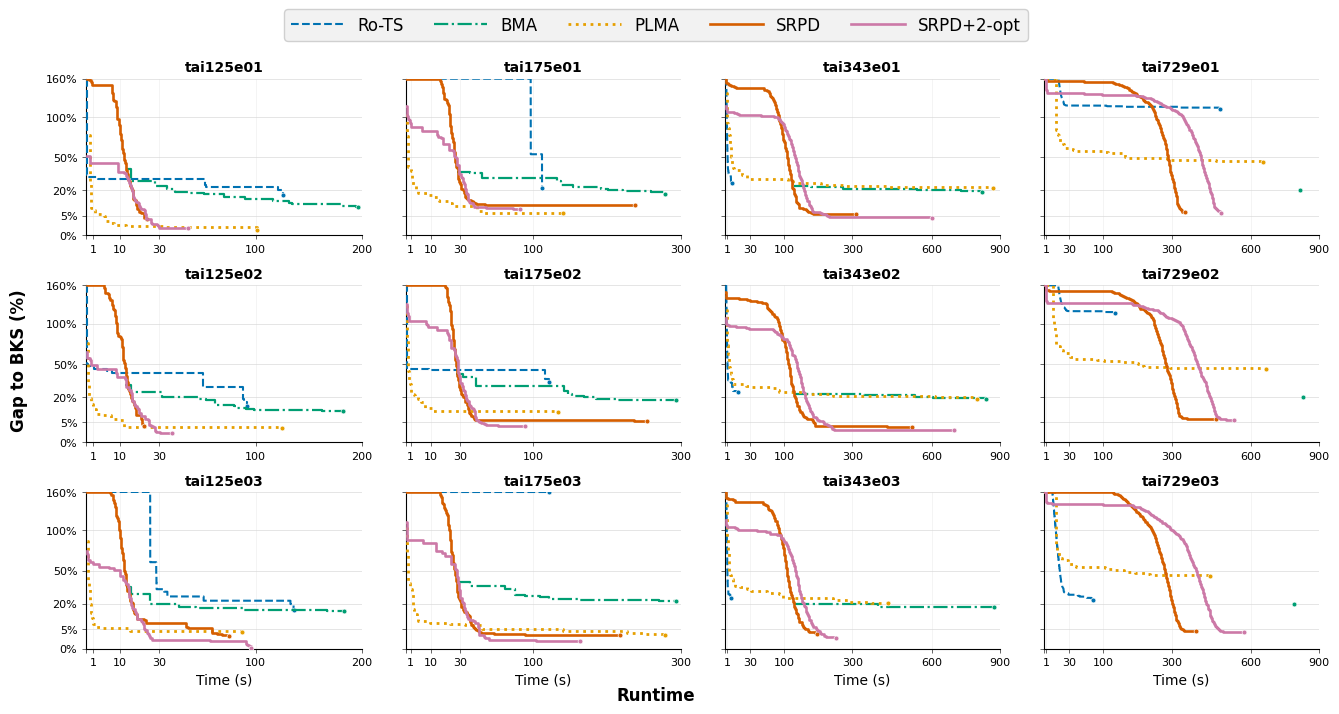

In [5]:
def plot_refined_grid():
    fig, axes = plt.subplots(
        nrows=len(instances_per_size),
        ncols=len(sizes),
        figsize=(13.4, 7.4),
        sharey=True,
        constrained_layout=False,
    )

    legend_handles = {}
    for row, instance_idx in enumerate(instances_per_size):
        for col, size in enumerate(sizes):
            ax = axes[row, col]
            instance_name = f"tai{size}e0{instance_idx}"
            base_obj = float(bks.loc[instance_name, "label"])
            x_limit = x_limits[size]

            for method_name, style in methods.items():
                times, gaps = gap_curve(instance_name, method_name, base_obj, x_limit)
                if times is None:
                    continue
                scaled_times = scale_time(times)
                scaled_gaps = scale_gap(gaps)
                (line,) = ax.step(
                    scaled_times,
                    scaled_gaps,
                    where="post",
                    label=method_name,
                    color=style["color"],
                    linestyle=style["linestyle"],
                    linewidth=style["linewidth"],
                    zorder=style["zorder"],
                )
                legend_handles.setdefault(method_name, line)

                final_gap = gaps[-1]
                ax.scatter(
                    scaled_times[-1],
                    scale_gap(final_gap),
                    s=12,
                    color=style["color"],
                    edgecolor="white",
                    linewidth=0.45,
                    zorder=style["zorder"] + 1,
                )

            ax.set_title(instance_name, pad=5, fontweight="semibold")
            ax.set_xlim(0, scale_time(x_limit))
            ax.set_ylim(0, scale_gap(y_limit_percent))
            ax.grid(True, axis="y", color="#D8D8D8", alpha=0.85)
            ax.grid(True, axis="x", color="#ECECEC", alpha=0.7)
            raw_y_ticks = gap_ticks_for_limit(y_limit_percent)
            ax.set_yticks(scale_gap(raw_y_ticks))
            ax.set_yticklabels([f"{tick:g}%" for tick in raw_y_ticks])
            raw_ticks = time_ticks_for_limit(x_limit)
            ax.set_xticks(scale_time(raw_ticks))
            ax.set_xticklabels([format_time_tick(tick, None) for tick in raw_ticks])
            ax.tick_params(axis="both", length=3, width=0.7, color="#666666")

            if row == len(instances_per_size) - 1:
                ax.set_xlabel("Time (s)")
    ordered_handles = [legend_handles[name] for name in methods if name in legend_handles]
    ordered_labels = [name for name in methods if name in legend_handles]
    fig.legend(
        ordered_handles,
        ordered_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.985),
        ncol=len(ordered_labels),
        frameon=True,
        facecolor="#F2F2F2",
        edgecolor="#D0D0D0",
        framealpha=1.0,
        handlelength=3.2,
        columnspacing=1.8,
        fontsize=12,
    )
    # fig.supxlabel(f"Runtime (s, power scale: t^{time_axis_power})", y=0.035, fontsize=11)
    fig.supxlabel(f"Runtime", y=0.035, fontsize=12, fontweight="semibold")
    # fig.supylabel("Gap to BKS (%)\n(power scale)", x=0.018, fontsize=11)
    fig.supylabel("Gap to BKS (%)", x=0.018, fontsize=12, fontweight="semibold")
    fig.subplots_adjust(left=0.075, right=0.995, bottom=0.11, top=0.88, wspace=0.16, hspace=0.32)
    return fig, axes

fig, axes = plot_refined_grid()
fig.savefig(OUTPUT_PDF, dpi=800, bbox_inches="tight")
fig.savefig(OUTPUT_PNG, dpi=240, bbox_inches="tight")
plt.show()

# Result table

In [6]:
table_methods = [
    ("Ro-TS", "rots", r"\texttt{Ro-TS}"),
    ("BMA", "bma", r"\texttt{BMA}"),
    ("PLMA", "plma", r"\texttt{PLMA}"),
    ("SRPD", "srpd", r"\texttt{SRPD}"),
    ("SRPD+2-opt", "srpd_2opt", r"\texttt{SRPD+2-opt}"),
]


def final_record_for_table(instance_name, method_name):
    times, objectives = parse_improvement_file(methods[method_name]["path"](instance_name))
    if times is None:
        return None, None
    order = np.argsort(times)
    times = times[order]
    objectives = objectives[order]
    record_idx = -2 if len(times) >= 2 else -1
    return int(objectives[record_idx]), int(times[record_idx])


def build_refined_table():
    instance_list = [f"tai{size}e{idx:02d}" for size in sizes for idx in instances_per_size]
    table = bks.loc[instance_list].copy()

    for method_name, column_prefix, _ in table_methods:
        obj_values = []
        time_values = []
        for instance_name in instance_list:
            final_obj, final_time = final_record_for_table(instance_name, method_name)
            obj_values.append(final_obj)
            time_values.append(final_time)
        table[f"{column_prefix}_obj"] = obj_values
        table[f"{column_prefix}_time"] = time_values
    return table


def format_int(value):
    return "" if pd.isna(value) else f"{int(value):,}"


def format_refined_table(table):
    formatted = table.copy()
    for column in formatted.columns:
        formatted[column] = formatted[column].map(format_int)
    return formatted


def render_refined_latex_table(table):
    col_spec = "lr" + "rr" * len(table_methods)
    latex_lines = [
        r"\begin{table*}[htbp]",
        r"  \centering",
        r"  \caption{Objective values of the \textit{final} incumbent solutions obtained by each method with the corresponding discovery time on the taiXXeYY instances.}",
        r"  \label{tab:taixxeyy-refined}",
        r"  \resizebox{\linewidth}{!}{%",
        rf"\begin{{tabular}}{{{col_spec}}}",
        r"\toprule",
    ]

    first_header = [r"\multirow{2}{*}{\bf Instance}", r"\multirow{2}{*}{\bf BKS}"]
    first_header.extend([rf"\multicolumn{{2}}{{c}}{{{latex_label}}}" for _, _, latex_label in table_methods])
    latex_lines.append(" & ".join(first_header) + r"\\")

    cmidrules = [rf"\cmidrule(lr){{{start}-{start + 1}}}" for start in range(3, 3 + 2 * len(table_methods), 2)]
    latex_lines.append(" ".join(cmidrules))

    second_header = ["", ""]
    for _ in table_methods:
        second_header.extend([r"Obj. $\downarrow$", r"Time (s) $\downarrow$"])
    latex_lines.append(" & ".join(second_header) + r"\\")
    latex_lines.append(r"\midrule")

    for instance_name, row in table.iterrows():
        method_objs = [row[f"{column_prefix}_obj"] for _, column_prefix, _ in table_methods]
        ranked_objs = sorted(set(method_objs))
        best_obj = ranked_objs[0]
        second_best_obj = ranked_objs[1] if len(ranked_objs) > 1 else None
        cells = [instance_name, format_int(row["label"])]
        for _, column_prefix, _ in table_methods:
            obj_value = row[f"{column_prefix}_obj"]
            obj_text = format_int(obj_value)
            if obj_value == best_obj:
                obj_text = rf"\bf {obj_text}"
            elif obj_value == second_best_obj:
                obj_text = rf"\underline{{{obj_text}}}"
            cells.extend([obj_text, format_int(row[f"{column_prefix}_time"])])
        latex_lines.append(" & ".join(cells) + r" \\")

    latex_lines.extend([
        r"\bottomrule",
        r"\end{tabular}",
        r"}",
        r"\end{table*}",
    ])
    return "\n".join(latex_lines) + "\n"


raw_refined_table = build_refined_table()
refined_table = format_refined_table(raw_refined_table)
OUTPUT_TABLE_TEX.write_text(render_refined_latex_table(raw_refined_table), encoding="utf-8")
refined_table

,label,rots_obj,rots_time,bma_obj,bma_time,plma_obj,plma_time,srpd_obj,srpd_time,srpd_2opt_obj,srpd_2opt_time
instance,,,,,,,,,,,
tai125e01,"35,426","39,746",320,"37,992","1,013","35,804",33,"36,814",22,"35,744",43
tai125e02,"36,178","39,354",592,"36,830","1,000","37,248",119,"37,482",20,"36,672",31
tai125e03,"30,498","35,138",133,"33,500","1,553","31,640",88,"31,302",76,"30,534",94
tai175e01,"57,540","65,420",355,"60,648","1,881","60,694",318,"63,372",230,"62,304",78
tai175e02,"50,110","66,142",118,"54,220","1,756","55,500",126,"52,962",244,"51,798",86
tai175e03,"53,900","218,360",829,"59,108","1,740","55,490",243,"55,406",134,"54,490",103
tai343e01,"141,048","177,228",4,"161,526","1,714","170,886","1,159","148,942",199,"147,068",291
tai343e02,"148,584","183,594",12,"170,858","1,814","177,730",612,"153,412",517,"151,692",300
tai343e03,"142,092","176,884",3,"163,758","1,768","171,562",362,"146,680",187,"144,866",243
